In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [2]:
import pandas as pd

df = pd.read_csv("indian_railway_failure_detection_maintenance_v2.csv")

print(df.head())
print(df.shape)
print(df.columns)

   train_id                 region   season train_type  train_age_years  \
0         1       Northern Railway  Monsoon  Passenger               25   
1         2        Western Railway   Summer  Passenger                4   
2         3  South Central Railway   Summer      Metro               29   
3         4        Eastern Railway   Summer    Freight               19   
4         5       Northern Railway   Summer    Freight               31   

   average_speed_kmph  distance_travelled_km  ambient_temperature_c  \
0           68.378675                 128246                   23.6   
1           71.893467                  60105                   29.5   
2           71.066133                  36621                   32.2   
3           50.082049                  33287                   37.8   
4           44.387655                  11723                   38.4   

   humidity_percent  rainfall_mm  ...  brake_pressure_psi  battery_voltage  \
0              57.8         50.3  ...       

In [3]:
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nFailure distribution:")
print(df["failure_type"].value_counts())

print("\nMaintenance distribution:")
print(df["maintenance_required"].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   train_id                100000 non-null  int64  
 1   region                  100000 non-null  str    
 2   season                  100000 non-null  str    
 3   train_type              100000 non-null  str    
 4   train_age_years         100000 non-null  int64  
 5   average_speed_kmph      100000 non-null  float64
 6   distance_travelled_km   100000 non-null  int64  
 7   ambient_temperature_c   100000 non-null  float64
 8   humidity_percent        95000 non-null   float64
 9   rainfall_mm             92000 non-null   float64
 10  wheel_wear_percent      97000 non-null   float64
 11  track_vibration_level   94000 non-null   float64
 12  rail_wear_mm            100000 non-null  float64
 13  bearing_temperature_c   93000 non-null   float64
 14  axle_temperature_c      100000 n

train_id                      0
region                        0
season                        0
train_type                    0
train_age_years               0
average_speed_kmph            0
distance_travelled_km         0
ambient_temperature_c         0
humidity_percent           5000
rainfall_mm                8000
wheel_wear_percent         3000
track_vibration_level      6000
rail_wear_mm                  0
bearing_temperature_c      7000
axle_temperature_c            0
brake_pad_wear_percent        0
brake_pressure_psi            0
battery_voltage            4000
last_maintenance_days         0
sensor_health_index           0
inspection_score              0
delay_minutes                 0
failure_type              69217
maintenance_required          0
failure_severity          69217
risk_score                    0
dtype: int64

Failure distribution:
failure_type
Track Defect       16236
Signal Failure      4221
Brake Failure       4194
Wheel Defect        3164
Bearing Failure    

In [4]:
X = df.drop("maintenance_required", axis=1)
y = df["maintenance_required"]

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [6]:
categorical_columns = X.select_dtypes(include=["object"]).columns
numerical_columns = X.select_dtypes(exclude=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numerical_columns),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_columns)
    ]
)

C:\Users\hp\AppData\Local\Temp\ipykernel_6216\3958210719.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include=["object"]).columns


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
from sklearn.ensemble import RandomForestClassifier

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    ))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](25,)","['train_id','region','season',...,'failure_type','failure_severity', 'risk_score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,25
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pass

In [9]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9853

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     13843
           1       1.00      0.95      0.98      6157

    accuracy                           0.99     20000
   macro avg       0.99      0.98      0.98     20000
weighted avg       0.99      0.99      0.99     20000



In [10]:
prediction = model.predict(X_test.iloc[[0]])[0]

if prediction == 1:
    print("⚠️ MAINTENANCE REQUIRED")
    print("Risk Level: HIGH")
    print("Recommendation: Schedule preventive maintenance.")
else:
    print("✅ NO MAINTENANCE REQUIRED")
    print("Risk Level: LOW")
    print("Recommendation: Continue normal monitoring.")

⚠️ MAINTENANCE REQUIRED
Risk Level: HIGH
Recommendation: Schedule preventive maintenance.


In [11]:
sample = X_test.iloc[[0]]

print("Railway/Train Information:")
print(sample.T)

Railway/Train Information:
                                  56458
train_id                          56459
region                  Western Railway
season                           Summer
train_type                    Passenger
train_age_years                      29
average_speed_kmph            74.282821
distance_travelled_km             98325
ambient_temperature_c              41.2
humidity_percent                   67.5
rainfall_mm                         4.6
wheel_wear_percent                 40.0
track_vibration_level              2.29
rail_wear_mm                      19.54
bearing_temperature_c              71.4
axle_temperature_c                 72.2
brake_pad_wear_percent             48.4
brake_pressure_psi                 99.9
battery_voltage                   24.61
last_maintenance_days               139
sensor_health_index                74.8
inspection_score                   71.6
delay_minutes                       3.5
failure_type               Track Defect
failure_sever

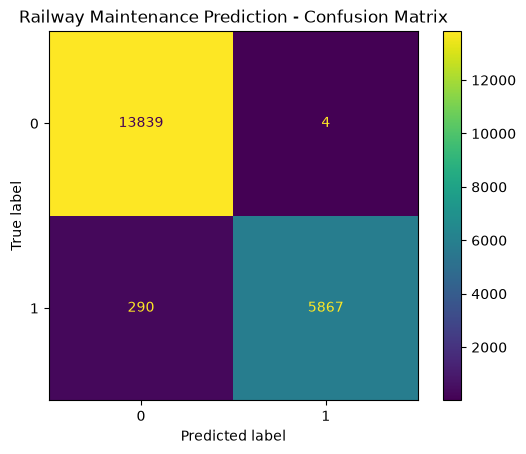

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("Railway Maintenance Prediction - Confusion Matrix")
plt.show()

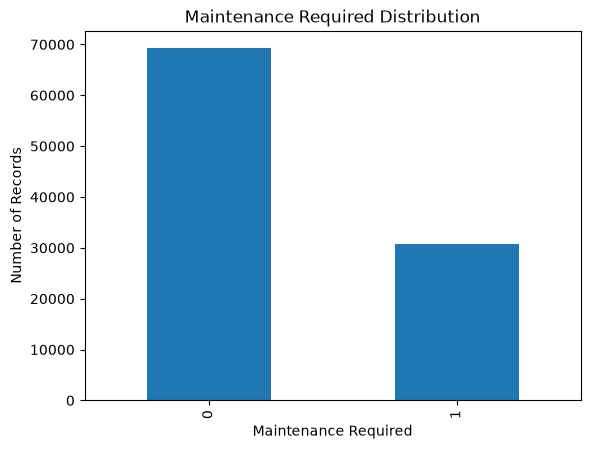

In [13]:
import matplotlib.pyplot as plt

df["maintenance_required"].value_counts().plot(kind="bar")

plt.title("Maintenance Required Distribution")
plt.xlabel("Maintenance Required")
plt.ylabel("Number of Records")
plt.show()

Univariative

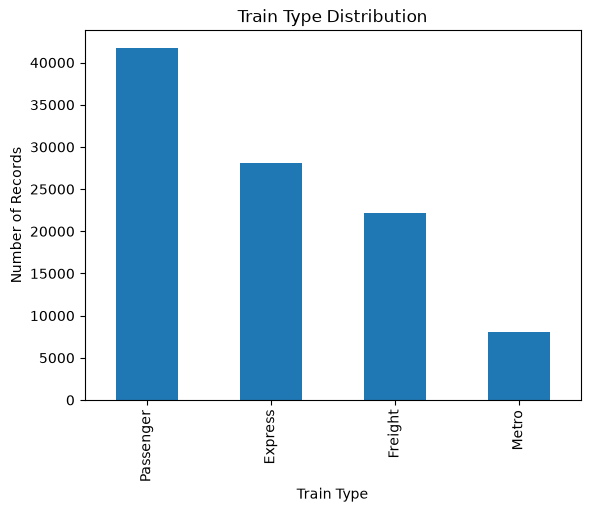

In [14]:
df["train_type"].value_counts().plot(kind="bar")

plt.title("Train Type Distribution")
plt.xlabel("Train Type")
plt.ylabel("Number of Records")
plt.show()

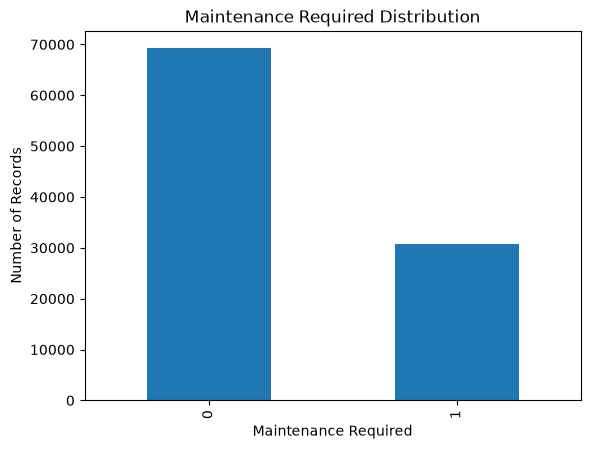

In [15]:
df["maintenance_required"].value_counts().plot(kind="bar")

plt.title("Maintenance Required Distribution")
plt.xlabel("Maintenance Required")
plt.ylabel("Number of Records")
plt.show()

Bivariavtive (maintenance vs wheel wear percent)

In [16]:
df.groupby("maintenance_required")["wheel_wear_percent"].mean()

maintenance_required
0    37.917698
1    47.369750
Name: wheel_wear_percent, dtype: float64

Correlation of entire data

Correlation Matrix:
                        train_id  train_age_years  average_speed_kmph  \
train_id                1.000000         0.001744            0.003894   
train_age_years         0.001744         1.000000           -0.002167   
average_speed_kmph      0.003894        -0.002167            1.000000   
distance_travelled_km  -0.001622        -0.007261            0.003735   
ambient_temperature_c  -0.000780         0.003275           -0.002386   
humidity_percent       -0.005026         0.001022            0.003692   
rainfall_mm            -0.003615         0.002947            0.001043   
wheel_wear_percent     -0.000795         0.789377           -0.002157   
track_vibration_level  -0.002199         0.637723            0.000875   
rail_wear_mm            0.001889         0.791076           -0.003002   
bearing_temperature_c  -0.001655         0.552400           -0.000691   
axle_temperature_c      0.002285         0.477975           -0.006360   
brake_pad_wear_percent  0.00215

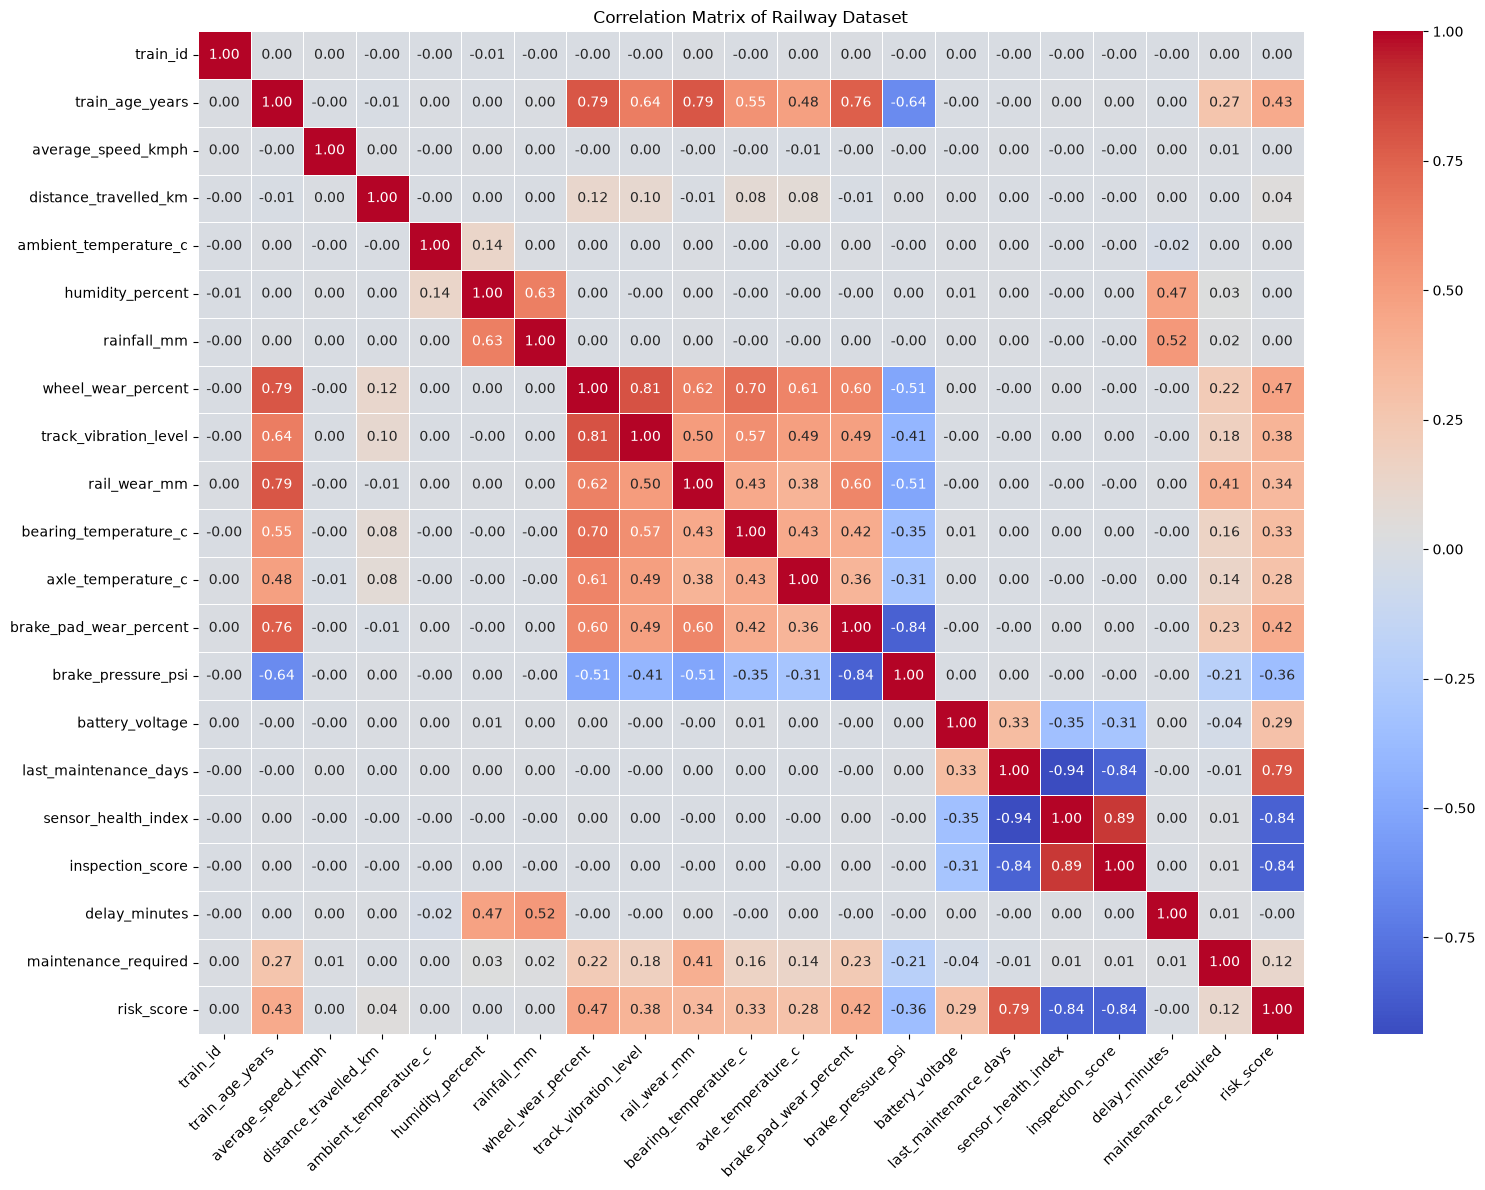

In [17]:
import seaborn as sns

# Select all numerical columns
numeric_df = df.select_dtypes(include="number")

# Calculate correlation matrix
correlation_matrix = numeric_df.corr()

# Display correlation values
print("Correlation Matrix:")
print(correlation_matrix)

# Plot correlation heatmap
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Railway Dataset")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Data Visualization


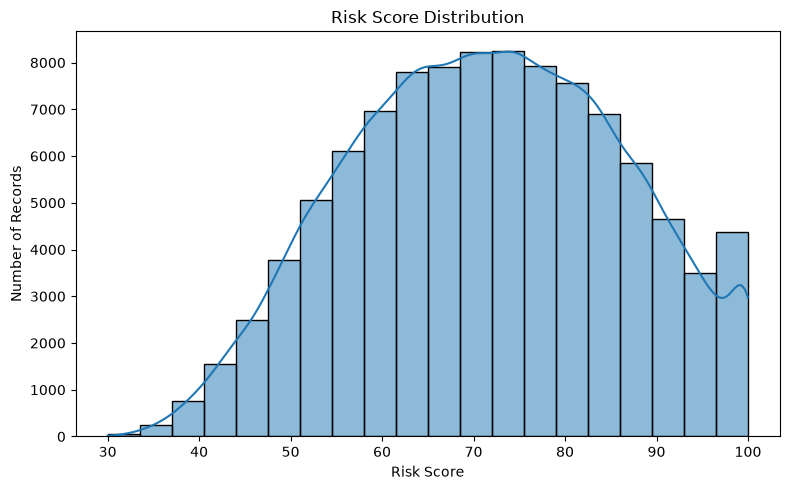

In [18]:
# Count/visualize risk score

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="risk_score",
    bins=20,
    kde=True
)

plt.title("Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

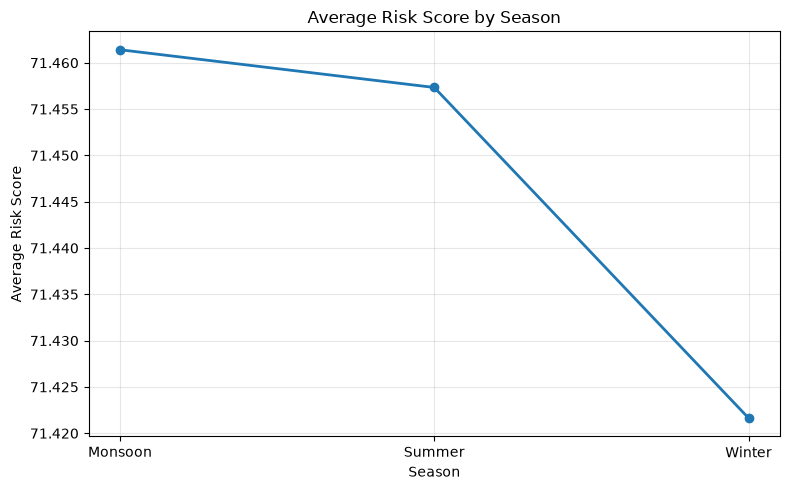

In [19]:
df = pd.read_csv("indian_railway_failure_detection_maintenance_v2.csv")

avg_risk = df.groupby("season")["risk_score"].mean()

plt.figure(figsize=(8, 5))

plt.plot(
    avg_risk.index,
    avg_risk.values,
    marker="o",
    linewidth=2
)

plt.title("Average Risk Score by Season")
plt.xlabel("Season")
plt.ylabel("Average Risk Score")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

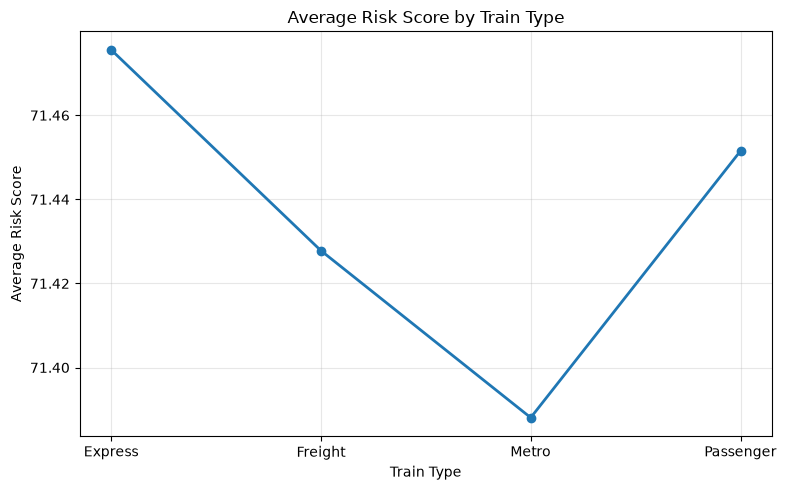

In [20]:
# Calculate average risk score for each train type
avg_risk = df.groupby("train_type")["risk_score"].mean()

# Line chart
plt.figure(figsize=(8, 5))

plt.plot(
    avg_risk.index,
    avg_risk.values,
    marker="o",
    linewidth=2
)

plt.title("Average Risk Score by Train Type")
plt.xlabel("Train Type")
plt.ylabel("Average Risk Score")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

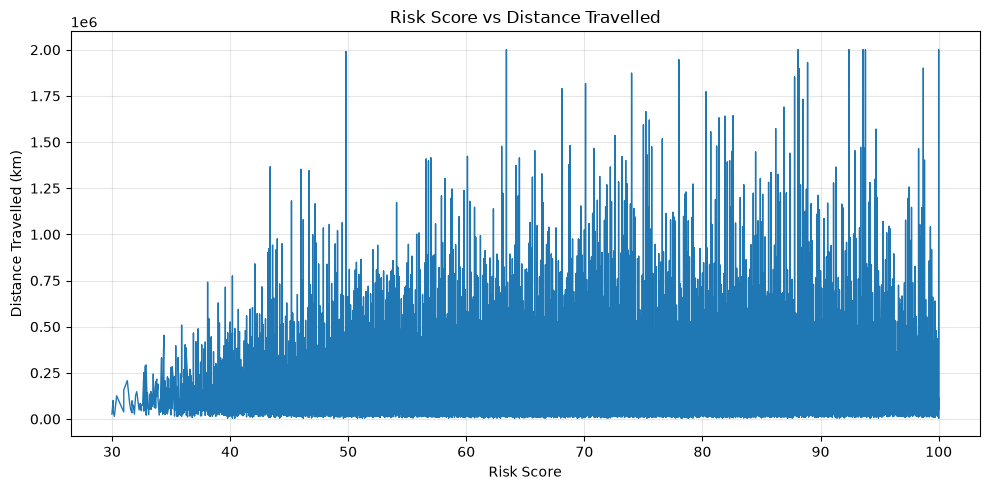

In [21]:
# Sort by risk score
df_sorted = df.sort_values("risk_score")

# Line graph
plt.figure(figsize=(10, 5))

plt.plot(
    df_sorted["risk_score"],
    df_sorted["distance_travelled_km"],
    linewidth=1
)

plt.title("Risk Score vs Distance Travelled")
plt.xlabel("Risk Score")
plt.ylabel("Distance Travelled (km)")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

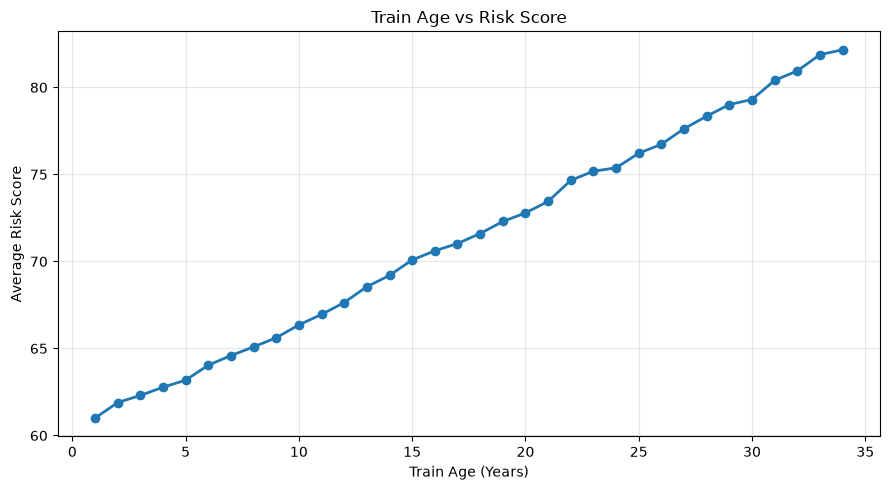

In [22]:
# Average risk score for each train age
avg_risk = df.groupby("train_age_years")["risk_score"].mean()

# Create line graph
plt.figure(figsize=(9, 5))

plt.plot(
    avg_risk.index,
    avg_risk.values,
    marker="o",
    linewidth=2
)

plt.title("Train Age vs Risk Score")
plt.xlabel("Train Age (Years)")
plt.ylabel("Average Risk Score")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

***Data*** ***Preprocessing***

In [23]:
# 1. Remove duplicate rows
df = df.drop_duplicates()

# 2. Separate features and target
X = df.drop("risk_score", axis=1)
y = df["risk_score"]

# 3. Identify numerical and categorical columns
numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = X.select_dtypes(include=["object", "category"]).columns

print("Numerical columns:")
print(list(numerical_columns))

print("\nCategorical columns:")
print(list(categorical_columns))

# 4. Import preprocessing tools
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 5. Numerical preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# 6. Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# 7. Combine both
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numerical_columns),
    ("categorical", categorical_pipeline, categorical_columns)
])

# 8. Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# 9. Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# 10. Check the result
print("Training data:", X_train_processed.shape)
print("Testing data:", X_test_processed.shape)
print("Preprocessing completed!")

C:\Users\hp\AppData\Local\Temp\ipykernel_6216\2026154038.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include=["object", "category"]).columns


Numerical columns:
['train_id', 'train_age_years', 'average_speed_kmph', 'distance_travelled_km', 'ambient_temperature_c', 'humidity_percent', 'rainfall_mm', 'wheel_wear_percent', 'track_vibration_level', 'rail_wear_mm', 'bearing_temperature_c', 'axle_temperature_c', 'brake_pad_wear_percent', 'brake_pressure_psi', 'battery_voltage', 'last_maintenance_days', 'sensor_health_index', 'inspection_score', 'delay_minutes', 'maintenance_required']

Categorical columns:
['region', 'season', 'train_type', 'failure_type', 'failure_severity']


Training data: (80000, 42)
Testing data: (20000, 42)
Preprocessing completed!


Missing values

In [24]:
# Check missing values in each column
missing_values = df.isnull().sum()

print(missing_values)

train_id                      0
region                        0
season                        0
train_type                    0
train_age_years               0
average_speed_kmph            0
distance_travelled_km         0
ambient_temperature_c         0
humidity_percent           5000
rainfall_mm                8000
wheel_wear_percent         3000
track_vibration_level      6000
rail_wear_mm                  0
bearing_temperature_c      7000
axle_temperature_c            0
brake_pad_wear_percent        0
brake_pressure_psi            0
battery_voltage            4000
last_maintenance_days         0
sensor_health_index           0
inspection_score              0
delay_minutes                 0
failure_type              69217
maintenance_required          0
failure_severity          69217
risk_score                    0
dtype: int64


In [25]:
# Numerical columns
numeric_columns = df.select_dtypes(include="number").columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

print("Missing numerical values handled.")

Missing numerical values handled.


In [26]:
# Categorical columns
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing categorical values handled.")

Missing categorical values handled.


C:\Users\hp\AppData\Local\Temp\ipykernel_6216\3147264411.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


In [27]:
print(df.isnull().sum())

train_id                  0
region                    0
season                    0
train_type                0
train_age_years           0
average_speed_kmph        0
distance_travelled_km     0
ambient_temperature_c     0
humidity_percent          0
rainfall_mm               0
wheel_wear_percent        0
track_vibration_level     0
rail_wear_mm              0
bearing_temperature_c     0
axle_temperature_c        0
brake_pad_wear_percent    0
brake_pressure_psi        0
battery_voltage           0
last_maintenance_days     0
sensor_health_index       0
inspection_score          0
delay_minutes             0
failure_type              0
maintenance_required      0
failure_severity          0
risk_score                0
dtype: int64

Outliers


In [28]:
# Numerical columns except target
numeric_columns = df.select_dtypes(include="number").columns

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(col, ":", len(outliers), "outliers")

train_id : 0 outliers
train_age_years : 0 outliers
average_speed_kmph : 235 outliers
distance_travelled_km : 6214 outliers
ambient_temperature_c : 55 outliers
humidity_percent : 91 outliers
rainfall_mm : 11250 outliers
wheel_wear_percent : 85 outliers


track_vibration_level : 372 outliers
rail_wear_mm : 451 outliers
bearing_temperature_c : 1445 outliers
axle_temperature_c : 1385 outliers
brake_pad_wear_percent : 0 outliers
brake_pressure_psi : 212 outliers
battery_voltage : 921 outliers
last_maintenance_days : 0 outliers
sensor_health_index : 0 outliers
inspection_score : 0 outliers
delay_minutes : 5889 outliers


maintenance_required : 0 outliers
risk_score : 0 outliers


In [29]:
numeric_columns = df.select_dtypes(include="number").columns

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower) &
        (df[col] <= upper)
    ]

print("Outliers handled.")

Outliers handled.


Encoding

In [30]:
categorical_columns = df.select_dtypes(include="object").columns

print(categorical_columns)

Index(['region', 'season', 'train_type', 'failure_type', 'failure_severity'], dtype='str')


C:\Users\hp\AppData\Local\Temp\ipykernel_6216\1123855639.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


In [31]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

print(df_encoded.head())

   train_id  train_age_years  average_speed_kmph  distance_travelled_km  \
1         2                4           71.893467                  60105   
2         3               29           71.066133                  36621   
3         4               19           50.082049                  33287   
4         5               31           44.387655                  11723   
5         6               18           53.947580                  60176   

   ambient_temperature_c  humidity_percent  rainfall_mm  wheel_wear_percent  \
1                   29.5              56.0          7.1                11.5   
2                   32.2              43.3          4.5                84.8   
3                   37.8              47.0          5.4                32.0   
4                   38.4              61.0          1.2                70.7   
5                   22.2              33.9          2.4                44.0   

   track_vibration_level  rail_wear_mm  ...  train_type_Freight  \
1      

In [32]:
print(df_encoded.columns)

Index(['train_id', 'train_age_years', 'average_speed_kmph',
       'distance_travelled_km', 'ambient_temperature_c', 'humidity_percent',
       'rainfall_mm', 'wheel_wear_percent', 'track_vibration_level',
       'rail_wear_mm', 'bearing_temperature_c', 'axle_temperature_c',
       'brake_pad_wear_percent', 'brake_pressure_psi', 'battery_voltage',
       'last_maintenance_days', 'sensor_health_index', 'inspection_score',
       'delay_minutes', 'maintenance_required', 'risk_score',
       'region_Eastern Railway', 'region_Northern Railway',
       'region_South Central Railway', 'region_Southern Railway',
       'region_Western Railway', 'season_Summer', 'season_Winter',
       'train_type_Freight', 'train_type_Metro', 'train_type_Passenger',
       'failure_type_Brake Failure', 'failure_type_Signal Failure',
       'failure_type_Track Defect', 'failure_type_Wheel Defect',
       'failure_severity_High', 'failure_severity_Low',
       'failure_severity_Medium'],
      dtype='str')


In [33]:
X = df_encoded.drop("risk_score", axis=1)
y = df_encoded["risk_score"]

Scaling

In [34]:
# Scaling

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

# Create scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaler to test data
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")
print("Scaled training data:", X_train_scaled.shape)
print("Scaled testing data:", X_test_scaled.shape)

Training data: (59104, 37)
Testing data: (14777, 37)


Scaling completed!
Scaled training data: (59104, 37)
Scaled testing data: (14777, 37)


Machine Learning

In [35]:
from sklearn.ensemble import RandomForestRegressor

In [36]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [37]:
model.fit(X_train_scaled, y_train)

print("Model training completed!")

Model training completed!


In [38]:
y_pred = model.predict(X_test_scaled)

print("Predicted Risk Scores:")
print(y_pred[:10])

Predicted Risk Scores:
[71.188 78.501 91.216 97.056 91.416 72.927 47.976 83.207 68.172 44.827]


In [39]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R² Score:", r2)

Mean Absolute Error: 0.47377451444812924
R² Score: 0.9967090892485291


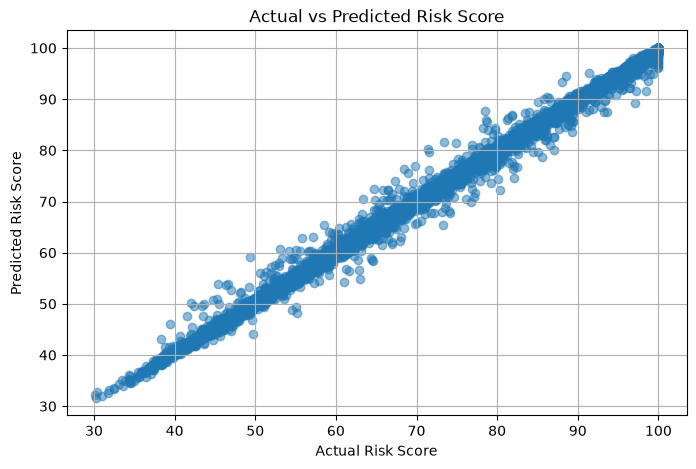

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Risk Score")
plt.ylabel("Predicted Risk Score")
plt.title("Actual vs Predicted Risk Score")

plt.grid(True)
plt.show()

In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create model
lr_model = LinearRegression()

# Train
lr_model.fit(X_train_scaled, y_train)

# Predict
lr_pred = lr_model.predict(X_test_scaled)

# Evaluate
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = mean_squared_error(y_test, lr_pred) ** 0.5
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R² Score:", lr_r2)

Linear Regression
MAE: 0.3881442471677596
RMSE: 0.917043477146706
R² Score: 0.9961054705114374


In [42]:
from sklearn.tree import DecisionTreeRegressor

# Create model
dt_model = DecisionTreeRegressor(
    random_state=42
)

# Train
dt_model.fit(X_train_scaled, y_train)

# Predict
dt_pred = dt_model.predict(X_test_scaled)

# Evaluate
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = mean_squared_error(y_test, dt_pred) ** 0.5
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Regressor")
print("MAE:", dt_mae)
print("RMSE:", dt_rmse)
print("R² Score:", dt_r2)

Decision Tree Regressor
MAE: 1.2343100764701902
RMSE: 1.7351783421311915
R² Score: 0.9860567703307406


In [43]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Use a smaller sample for SVR
sample_size = 10000

X_train_svr = X_train_scaled[:sample_size]
y_train_svr = y_train.iloc[:sample_size]

# Create SVR model
svr_model = SVR(kernel="rbf")

# Train
svr_model.fit(X_train_svr, y_train_svr)

# Predict on test data
svr_pred = svr_model.predict(X_test_scaled)

# Evaluate
svr_mae = mean_absolute_error(y_test, svr_pred)
svr_rmse = mean_squared_error(y_test, svr_pred) ** 0.5
svr_r2 = r2_score(y_test, svr_pred)

print("Support Vector Regression")
print("MAE:", svr_mae)
print("RMSE:", svr_rmse)
print("R2 Score:", svr_r2)

Support Vector Regression
MAE: 1.3576613965444149
RMSE: 2.274876976046096
R2 Score: 0.9760342527478483


In [44]:
from sklearn.ensemble import GradientBoostingRegressor

# Create model
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

# Train
gb_model.fit(X_train_scaled, y_train)

# Predict
gb_pred = gb_model.predict(X_test_scaled)

# Evaluate
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = mean_squared_error(y_test, gb_pred) ** 0.5
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting Regressor")
print("MAE:", gb_mae)
print("RMSE:", gb_rmse)
print("R² Score:", gb_r2)

Gradient Boosting Regressor
MAE: 0.594040206202577
RMSE: 0.9228227375490488
R² Score: 0.9960562287417776


In [45]:
from sklearn.neighbors import KNeighborsRegressor

# Create model
knn_model = KNeighborsRegressor(n_neighbors=5)

# Train model
knn_model.fit(X_train_scaled, y_train)

# Prediction
knn_pred = knn_model.predict(X_test_scaled)

# Evaluation
knn_mae = mean_absolute_error(y_test, knn_pred)
knn_rmse = mean_squared_error(y_test, knn_pred) ** 0.5
knn_r2 = r2_score(y_test, knn_pred)

print("KNN Regressor")
print("MAE:", knn_mae)
print("RMSE:", knn_rmse)
print("R² Score:", knn_r2)



KNN Regressor
MAE: 3.789489070853353
RMSE: 4.812960604598491
R² Score: 0.8927246949703581


In [46]:
rf_mae = mean_absolute_error(y_test, y_pred)
rf_rmse = mean_squared_error(y_test, y_pred) ** 0.5
rf_r2 = r2_score(y_test, y_pred)

print("Random Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest
MAE: 0.47377451444812924
RMSE: 0.8429862290479516
R² Score: 0.9967090892485291


In [47]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVR",
        "Gradient Boosting"
    ],

    "MAE": [
        lr_mae,
        dt_mae,
        rf_mae,
        knn_mae,
        svr_mae,
        gb_mae
    ],

    "RMSE": [
        lr_rmse,
        dt_rmse,
        rf_rmse,
        knn_rmse,
        svr_rmse,
        gb_rmse
    ],

    "R2 Score": [
        lr_r2,
        dt_r2,
        rf_r2,
        knn_r2,
        svr_r2,
        gb_r2
    ]
})

display(results.round(4))

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.3881,0.9170,0.9961
1,Decision Tree,1.2343,1.7352,0.9861
2,Random Forest,0.4738,0.8430,0.9967
3,KNN,3.7895,4.8130,0.8927
4,SVR,1.3577,2.2749,0.9760
5,Gradient Boosting,0.5940,0.9228,0.9961


In [48]:
best_model = results.loc[results["R2 Score"].idxmax()]

print("BEST MODEL")
print("==========")
print("Model:", best_model["Model"])
print("MAE:", best_model["MAE"])
print("RMSE:", best_model["RMSE"])
print("R² Score:", best_model["R2 Score"])

BEST MODEL
Model: Random Forest
MAE: 0.47377451444812924
RMSE: 0.8429862290479516
R² Score: 0.9967090892485291


Hyper parameter tuning

In [49]:
X_train_scaled
X_test_scaled
y_train
y_test

47591    70.9
85196    78.1
99617    91.7
5569     98.5
62835    91.7
         ... 
76010    86.5
41778    80.6
74098    55.2
61416    61.5
61886    81.7
Name: risk_score, Length: 14777, dtype: float64

In [50]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_tuned = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=5,
    cv=2,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(rf_tuned.best_params_)

print("\nBest Cross-Validation R² Score:")
print(rf_tuned.best_score_)

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 20}

Best Cross-Validation R² Score:
0.9958557188481632


In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Best Random Forest model
best_rf = rf_tuned.best_estimator_

# Prediction
rf_tuned_pred = best_rf.predict(X_test_scaled)

# Evaluation
tuned_mae = mean_absolute_error(y_test, rf_tuned_pred)
tuned_rmse = mean_squared_error(y_test, rf_tuned_pred) ** 0.5
tuned_r2 = r2_score(y_test, rf_tuned_pred)

print("Tuned Random Forest Results")
print("===========================")
print("MAE:", tuned_mae)
print("RMSE:", tuned_rmse)
print("R² Score:", tuned_r2)

Tuned Random Forest Results
MAE: 0.4716486228427465
RMSE: 0.8424107580139159
R² Score: 0.9967135808459743


In [52]:
print("Original Random Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

print("\nTuned Random Forest")
print("MAE:", tuned_mae)
print("RMSE:", tuned_rmse)
print("R² Score:", tuned_r2)

Original Random Forest
MAE: 0.47377451444812924
RMSE: 0.8429862290479516
R² Score: 0.9967090892485291

Tuned Random Forest
MAE: 0.4716486228427465
RMSE: 0.8424107580139159
R² Score: 0.9967135808459743
